# 🏋️ Entrenamiento YOLO26 - Trabajo Final Visión por Computadora
## Detección, Segmentación y Estimación de Pose

Este notebook entrena un modelo **YOLO26** con clases personalizadas (no incluidas en COCO) usando **transfer learning**.

### 📋 Configuración del proyecto
- **Clases**: factura, termo, mate (Set A — orden `0: factura, 1: mate, 2: termo` del export de Roboflow)
- **Dataset**: `data/mate-termo/` — 155 imágenes (124 train + 31 valid), etiquetado con Roboflow
- **Épocas**: 80 (ajustable)
- **Batch size**: 16 (ajustar según VRAM)
- **Image size**: 640

> ℹ️ **YOLO26** está disponible en `ultralytics` desde enero 2026 (incluye `-seg` y `-pose`). La celda de instalación actualiza la librería con `pip install -U`; si igual no estuviera disponible, la celda de carga del modelo cae automáticamente a `yolo11n.pt`.

## 0. ⚙️ Entorno de ejecución (VS Code + Colab, Colab web, o local)

Esta celda resuelve el directorio de trabajo en los 3 escenarios:

| Escenario | Qué hace |
|---|---|
| **Extensión de Colab en VS Code** | El kernel corre en la VM de Colab (sin acceso a tus archivos locales) → **clona el repo desde GitHub** a `/content/` |
| **Colab web con el repo en Drive** | Poner `USAR_DRIVE = True` → monta Drive y usa esa copia |
| **Local** (Jupyter en tu PC) | Busca la raíz del repo automáticamente |

> ⚠️ En VS Code **no** usar `USAR_DRIVE = True`: `drive.mount()` es inestable fuera del frontend web de Colab.

In [1]:
import os
import subprocess
from pathlib import Path

# Poner en True SOLO en Colab web si querés trabajar sobre la copia del repo en
# Google Drive (flujo de Fede). Con la extensión de Colab para VS Code dejarlo
# en False: drive.mount() es inestable ahí y el repo se clona desde GitHub.
USAR_DRIVE = False

REPO_URL = 'https://github.com/samuelkanneman/TPF---Vision-por-Computadora-2026.git'
DRIVE_REPO = Path('/content/drive/MyDrive/UGR/PDI_TP2/TPF---Vision-por-Computadora-2026')

try:
    import google.colab  # noqa: F401  (¿estamos en un runtime de Colab?)
    EN_COLAB = True
except ImportError:
    EN_COLAB = False

if not EN_COLAB:
    # Local: buscar la raíz del repo (la carpeta que contiene data/mate-termo)
    for c in [Path.cwd(), *Path.cwd().parents]:
        if (c / 'data' / 'mate-termo').exists():
            os.chdir(c)
            break
    print("Entorno: local")
elif USAR_DRIVE or DRIVE_REPO.exists():
    # Colab web con el repo en Drive
    if not DRIVE_REPO.exists():
        from google.colab import drive
        drive.mount('/content/drive')
    os.chdir(DRIVE_REPO)
    print("Entorno: Colab (repo en Drive)")
else:
    # Colab sin Drive (p. ej. extensión de VS Code): clonar/actualizar desde GitHub
    repo = Path('/content/TPF---Vision-por-Computadora-2026')
    if repo.exists():
        subprocess.run(['git', '-C', str(repo), 'pull'], check=True)
    else:
        subprocess.run(['git', 'clone', REPO_URL, str(repo)], check=True)
    os.chdir(repo)
    print("Entorno: Colab (repo clonado desde GitHub)")

print(f"Directorio de trabajo: {Path.cwd()}")

Entorno: Colab (repo clonado desde GitHub)
Directorio de trabajo: /content/TPF---Vision-por-Computadora-2026


## 1. 📦 Instalación de dependencias

In [2]:
import subprocess
import sys

# En Colab ya viene todo preinstalado y compatible: SOLO actualizar ultralytics
# (YOLO26 requiere version >= enero 2026). Actualizar Pillow/numpy/torch en Colab
# rompe dependencias ya cargadas (ej: ImportError '_Ink' de PIL).
if EN_COLAB:
    pkgs = ['ultralytics']
else:
    pkgs = ['ultralytics', 'opencv-python', 'numpy', 'torch', 'torchvision',
            'Pillow', 'PyYAML', 'matplotlib']

subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', '-U', *pkgs], check=True)
print(f"✅ Dependencias listas: {', '.join(pkgs)}")

✅ Dependencias listas: ultralytics


## 2. 🖥️ Verificar GPU

Es importante contar con GPU para entrenar en tiempos razonables. Si no tenés GPU local, considerá usar Google Colab o Kaggle (ambos con GPU gratuita).

In [3]:
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA disponible: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memoria total: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    print("⚠️ No hay GPU disponible. El entrenamiento será lento. Considerá usar Colab/Kaggle.")

PyTorch version: 2.11.0+cu128
CUDA disponible: True
GPU: Tesla T4
Memoria total: 15.64 GB


## 3. 📁 Verificar el dataset

El dataset es el export de **Roboflow** en `data/mate-termo/` (estructura `train/` y `valid/` propia de Roboflow). Esperado: **124 imágenes de train y 31 de valid**.

> ℹ️ Los labels están en **formato polígono** (Roboflow los exportó como segmentación). Ultralytics los convierte automáticamente a bounding boxes cuando se entrena con `task=detect`, así que sirven tal cual.
>
> ⚠️ El export original de Roboflow llama `bolleria` a la clase 0; en `data/data.yaml` la renombramos a `factura` **respetando el orden** `0: factura, 1: mate, 2: termo`.

In [4]:
from pathlib import Path
from collections import Counter

DATASET_DIR = Path('data/mate-termo')
CLASS_NAMES = {0: 'factura', 1: 'mate', 2: 'termo'}

# Mostrar contenido de data.yaml
with open('data/data.yaml', 'r', encoding='utf-8') as f:
    print("=== data/data.yaml ===")
    print(f.read())

# Contar imagenes, labels e instancias por clase
for split in ['train', 'valid']:
    img_dir = DATASET_DIR / split / 'images'
    lbl_dir = DATASET_DIR / split / 'labels'
    n_imgs = len(list(img_dir.glob('*.jpg'))) + len(list(img_dir.glob('*.png')))
    lbls = list(lbl_dir.glob('*.txt'))

    counts = Counter()
    for lbl in lbls:
        for line in lbl.read_text().splitlines():
            if line.strip():
                counts[int(line.split()[0])] += 1

    dist = ', '.join(f"{CLASS_NAMES[c]}: {n}" for c, n in sorted(counts.items()))
    print(f"{split}: {n_imgs} imagenes, {len(lbls)} labels — instancias: {dist}")

=== data/data.yaml ===
# data.yaml - Dataset custom para YOLO26
# Proyecto Integrador - Vision por Computadora 2026
#
# Dataset: data/mate-termo/ (export de Roboflow, 124 train + 31 valid)
#   https://universe.roboflow.com/federicos-workspace-5cgiu/mate-termo-factura/dataset/1
#
# IMPORTANTE - orden de las clases:
#   El export de Roboflow define 0=bolleria, 1=mate, 2=termo.
#   "bolleria" es la factura (nombre del etiquetado original), por eso aca
#   se renombra a "factura" PERO se respeta el orden 0/1/2 de los labels.
#   NO cambiar el orden: los .txt de data/mate-termo/*/labels usan estos indices.
#
# NOTA: ultralytics resuelve un `path` relativo contra su datasets_dir global,
# no contra este archivo. Por eso el notebook de entrenamiento genera
# data/data_runtime.yaml con la ruta absoluta antes de entrenar (celda 4).

# Ruta al directorio raiz del dataset (el notebook la vuelve absoluta en runtime)
path: mate-termo

# Subcarpetas de train y validacion (relativas a `path`)
train: 

### 3.1. 👀 Sanity check visual del etiquetado

Dibuja los polígonos de los labels sobre 4 imágenes al azar con el nombre de clase. **Verificar antes de entrenar** que `factura`, `mate` y `termo` aparecen sobre los objetos correctos (si los nombres están cruzados, el orden de clases en `data/data.yaml` está mal).

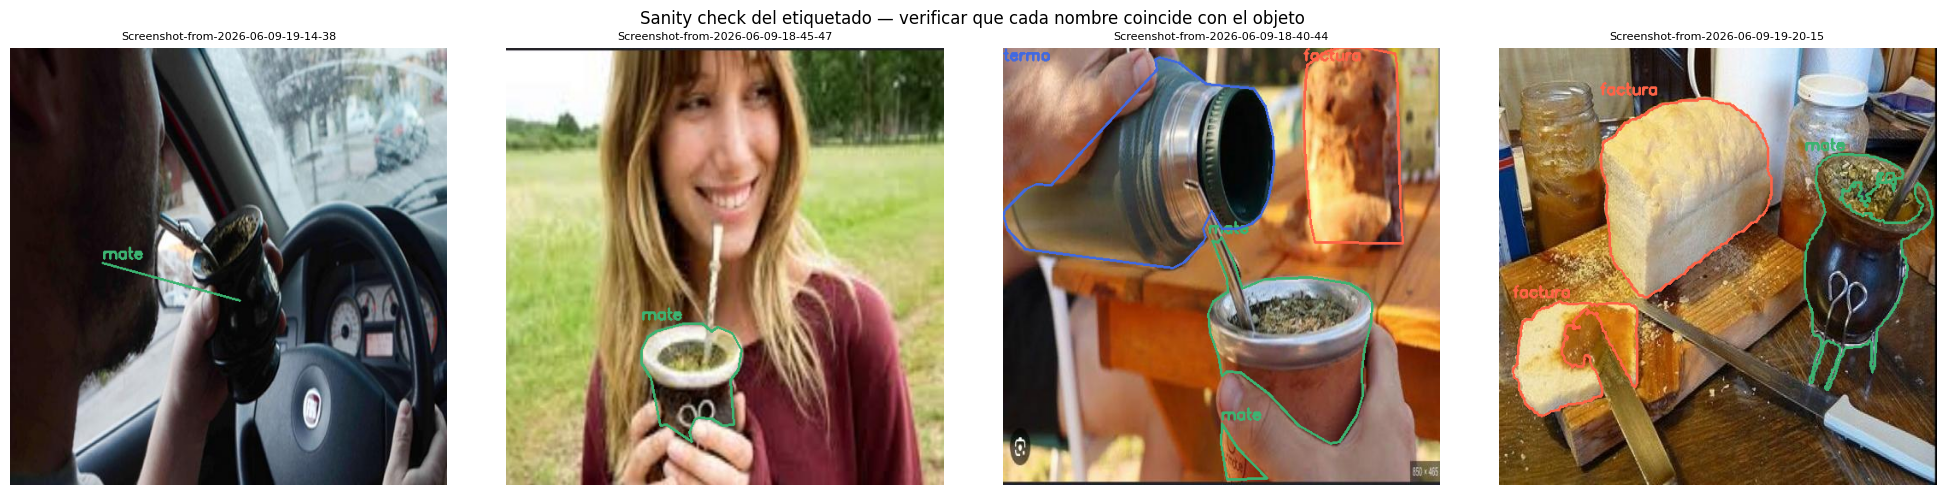

In [5]:
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt

COLORS = {0: (255, 99, 71), 1: (60, 179, 113), 2: (65, 105, 225)}  # RGB por clase

img_dir = DATASET_DIR / 'train' / 'images'
lbl_dir = DATASET_DIR / 'train' / 'labels'

random.seed(42)  # cambiar la semilla para ver otras imagenes
samples = random.sample(sorted(img_dir.glob('*.jpg')), 4)

fig, axes = plt.subplots(1, len(samples), figsize=(20, 5))
for ax, img_path in zip(axes, samples):
    img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    lbl_path = lbl_dir / (img_path.stem + '.txt')
    for line in lbl_path.read_text().splitlines():
        parts = line.split()
        if len(parts) < 5:
            continue
        cls = int(parts[0])
        # Polígono normalizado -> píxeles
        pts = (np.array(parts[1:], dtype=float).reshape(-1, 2) * [w, h]).astype(int)
        color = COLORS.get(cls, (255, 255, 0))
        cv2.polylines(img, [pts], isClosed=True, color=color, thickness=2)
        x, y = pts.min(axis=0)
        cv2.putText(img, CLASS_NAMES[cls], (int(x), max(15, int(y) - 5)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

    ax.imshow(img)
    ax.set_title(img_path.name[:35], fontsize=8)
    ax.axis('off')

plt.suptitle("Sanity check del etiquetado — verificar que cada nombre coincide con el objeto")
plt.tight_layout()
plt.show()

### 3.2. 📝 Generar config de entrenamiento con rutas absolutas

Ultralytics resuelve las rutas relativas de un `data.yaml` contra su `datasets_dir` global (no contra el repo), lo que suele dar el error *"dataset not found"*. Esta celda genera `data/data_runtime.yaml` con la ruta absoluta del dataset — funciona igual en Colab y en local.

In [6]:
import yaml

with open('data/data.yaml', 'r', encoding='utf-8') as f:
    cfg = yaml.safe_load(f)

# Volver absoluta la ruta del dataset
cfg['path'] = str((Path('data') / cfg['path']).resolve())

RUNTIME_YAML = Path('data/data_runtime.yaml')
with open(RUNTIME_YAML, 'w', encoding='utf-8') as f:
    yaml.safe_dump(cfg, f, sort_keys=False, allow_unicode=True)

print(f"Config generada en {RUNTIME_YAML}:\n")
print(yaml.safe_dump(cfg, sort_keys=False, allow_unicode=True))

Config generada en data/data_runtime.yaml:

path: /content/TPF---Vision-por-Computadora-2026/data/mate-termo
train: train/images
val: valid/images
names:
  0: factura
  1: mate
  2: termo
nc: 3



## 4. 🧠 Cargar modelo preentrenado (Transfer Learning)

Elegí el tamaño del modelo según tu VRAM disponible:
- `yolo26n.pt` (nano) - más rápido, menos VRAM
- `yolo26s.pt` (small) - balance
- `yolo26m.pt` (medium) - más precisión, más VRAM

In [7]:
from ultralytics import YOLO

# YOLO26 esta disponible en ultralytics desde enero 2026 (la celda 1 actualiza la libreria).
# Si por alguna razon no se puede descargar, se usa yolo11n.pt como fallback.
MODEL_NAME = 'yolo26n.pt'

try:
    model = YOLO(MODEL_NAME)
except Exception as e:
    print(f"⚠️ No se pudo cargar {MODEL_NAME} ({e})")
    MODEL_NAME = 'yolo11n.pt'
    model = YOLO(MODEL_NAME)

print(f"Modelo {MODEL_NAME} cargado correctamente")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Modelo yolo26n.pt cargado correctamente


## 5. 🚀 Entrenamiento

Ajustá los hiperparámetros según tu hardware. El entrenamiento se guarda automáticamente en `runs/detect/train/`.

In [8]:
results = model.train(
    data=str(RUNTIME_YAML),   # data/data_runtime.yaml (rutas absolutas, celda 3.2)
    epochs=80,
    imgsz=640,
    batch=16,
    optimizer='AdamW',
    lr0=0.001,
    patience=15,           # early stopping
    augment=True,          # augmentations automaticas
    project='runs/detect',
    name='train',
    exist_ok=True,
    plots=True,            # guardar graficas
    save=True,
)

Ultralytics 8.4.66 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data/data_runtime.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=80, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience=15, perspec

## 6. 📊 Validación y métricas

Evalúa el modelo entrenado sobre el conjunto de validación.

In [9]:
metrics = model.val()

print("=" * 50)
print("MÉTRICAS DEL MODELO ENTRENADO")
print("=" * 50)
print(f"mAP50:       {metrics.box.map50:.4f}")
print(f"mAP50-95:    {metrics.box.map:.4f}")
print(f"Precision:   {metrics.box.mp:.4f}")
print(f"Recall:      {metrics.box.mr:.4f}")
print()
print("Las graficas (loss, matriz confusion, PR) estan en:")
print("  runs/detect/train/")

Ultralytics 8.4.66 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n summary (fused): 122 layers, 2,375,421 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1445.1±275.1 MB/s, size: 43.4 KB)
val: Scanning /content/TPF---Vision-por-Computadora-2026/data/mate-termo/valid/labels.cache... 31 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 31/31 8.7Mit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 67, len(boxes) = 70. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 1.6it/s 1.3s1.8s
                   all         31         70      0.624       0.53       0.59      0.404
               factura          8         22      0.293      0.227      0.258      0.194
   

## 7. 🖼️ Test con imagen de validación

Corre predicciones sobre imágenes del set de validación y guarda los resultados para inspección visual.

In [10]:
test_results = model.predict(
    source='data/mate-termo/valid/images',
    conf=0.4,
    save=True,
    project='runs/detect',
    name='predict_test',
    exist_ok=True,
)

print(f"Predicciones guardadas en runs/detect/predict_test/")
print(f"Total de imágenes procesadas: {len(test_results)}")


image 1/31 /content/TPF---Vision-por-Computadora-2026/data/mate-termo/valid/images/Screenshot-from-2026-06-09-18-40-26_png.rf.431fa138407cd3edb05cfcd1c2629631.jpg: 640x640 (no detections), 10.0ms
image 2/31 /content/TPF---Vision-por-Computadora-2026/data/mate-termo/valid/images/Screenshot-from-2026-06-09-18-43-39_png.rf.daedffed001bb6da486566f5e40b97c2.jpg: 640x640 1 mate, 1 termo, 9.7ms
image 3/31 /content/TPF---Vision-por-Computadora-2026/data/mate-termo/valid/images/Screenshot-from-2026-06-09-18-44-35_png.rf.4a652ed7bfe65c4c8a34ea5c7b04defa.jpg: 640x640 1 termo, 10.7ms
image 4/31 /content/TPF---Vision-por-Computadora-2026/data/mate-termo/valid/images/Screenshot-from-2026-06-09-18-45-27_png.rf.5c59e3ca7da09299f403763222429578.jpg: 640x640 (no detections), 10.2ms
image 5/31 /content/TPF---Vision-por-Computadora-2026/data/mate-termo/valid/images/Screenshot-from-2026-06-09-18-45-36_png.rf.96d08893006ffd342ff99875bccd9771.jpg: 640x640 1 mate, 9.9ms
image 6/31 /content/TPF---Vision-por-C

## 8. 💾 Copiar best.pt al directorio del proyecto

El archivo `best.pt` es el entregable principal del entrenamiento (los pesos con mejor mAP).

In [12]:
import shutil
from pathlib import Path

# Carpeta real del entrenamiento: ultralytics la informa en results.save_dir
candidatos = []
if 'results' in globals() and getattr(results, 'save_dir', None):
    candidatos.append(Path(results.save_dir) / 'weights' / 'best.pt')
candidatos.append(Path('runs/detect/train/weights/best.pt'))

src = next((c for c in candidatos if c.exists()), None)

if src is None and Path('runs').exists():
    # Último recurso: buscar cualquier best.pt bajo runs/ (el más reciente)
    encontrados = sorted(Path('runs').rglob('best.pt'),
                         key=lambda p: p.stat().st_mtime, reverse=True)
    src = encontrados[0] if encontrados else None

if src:
    dst = Path('best.pt')
    shutil.copy(src, dst)
    print(f"✅ best.pt copiado desde: {src}")
    print(f"   a: {dst.resolve()} ({dst.stat().st_size / 1e6:.2f} MB)")
else:
    print("❌ No se encontró ningún best.pt bajo runs/")
    print(f"   cwd actual: {Path.cwd()}")
    if 'results' in globals():
        print(f"   results.save_dir: {getattr(results, 'save_dir', '(sin save_dir)')}")
    else:
        print("   La variable 'results' no existe -> la celda de entrenamiento (sección 5) no corrió en esta sesión.")
    print("   Revisá la salida de la celda de entrenamiento: ¿terminó las épocas y mostró 'Results saved to ...'?")

✅ best.pt copiado desde: /content/TPF---Vision-por-Computadora-2026/runs/detect/runs/detect/train/weights/best.pt
   a: /content/TPF---Vision-por-Computadora-2026/best.pt (5.39 MB)


## 9. 📥 Descargar los resultados (importante en Colab)

La VM de Colab es **efímera**: al desconectarte se pierde todo lo que no bajes. Esta celda arma un zip con `best.pt` + las gráficas de entrenamiento + las predicciones de test, y lo descarga.

> El zip contiene justo el material para la presentación (slides 6 y 7) y el `best.pt` que necesita el notebook de inferencia. Si corrés la inferencia **en la misma sesión** de Colab, no hace falta nada: `best.pt` ya queda en la raíz del repo clonado.

In [ ]:
import zipfile
from pathlib import Path

# Carpeta real del entrenamiento (detectada en la celda anterior)
train_dir = src.parent.parent if src else Path('runs/detect/train')

ZIP_PATH = Path('resultados_entrenamiento.zip')
ARTEFACTOS = [
    Path('best.pt'),
    # Todas las graficas del entrenamiento (results, confusion matrix, curvas
    # P/R/PR/F1, labels) — los nombres exactos cambian segun la version de
    # ultralytics, asi que se incluyen todas las .png
    *sorted(train_dir.glob('*.png')),
    *sorted(Path('runs/detect/predict_test').glob('*.jpg')),
]

with zipfile.ZipFile(ZIP_PATH, 'w', zipfile.ZIP_DEFLATED) as zf:
    for f in ARTEFACTOS:
        if f.exists():
            zf.write(f)
            print(f"  + {f}")
        else:
            print(f"  (no encontrado, se omite: {f})")

print(f"\n📦 {ZIP_PATH} generado ({ZIP_PATH.stat().st_size / 1e6:.1f} MB)")

if EN_COLAB:
    try:
        from google.colab import files
        files.download(str(ZIP_PATH))
    except Exception as e:
        print(f"\n⚠️ Descarga automática no disponible en este entorno ({e}).")
        print(f"   Descargá a mano: {ZIP_PATH.resolve()}")
        print("   (En VS Code: panel de archivos del runtime de Colab, o subilo a tu Drive.)")